In [1]:
import torch, sys, json, time
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample


from ft_model_def import FTTransformer
from data_to_tensor import ACSDataset
from torch.utils.data import DataLoader

In [2]:
DATA_DIR    = '../3_Data_Preprocessing/preprocessing_data'
TARGET_COL  = 'poverty_risk_score'   # 4-class only
N_CLASSES   = 4
CLASS_NAMES = ['Stable', 'Near Poverty', 'Poverty', 'Deep Poverty']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

Using device: cuda
  GPU: NVIDIA GeForce GTX 1080 Ti
  VRAM: 11.7 GB


In [3]:
df_train_raw = pd.read_csv(f'{DATA_DIR}/train_engineered.csv', low_memory=False)
df_test      = pd.read_csv(f'{DATA_DIR}/test_engineered.csv',  low_memory=False)

# ── Load master metadata (single source of truth for feature lists) ───────────
with open(f'{DATA_DIR}/feature_engineering_metadata.json') as f:
    metadata = json.load(f)

optimal_features = metadata['optimal_features']   # 19 features incl. SEX, no disability_score
categorical_features = metadata['categorical_features']   # 14 cols used for label encoding


In [4]:
cat_cols  = [f for f in optimal_features if f in categorical_features]
cont_cols = [f for f in optimal_features if f not in categorical_features]

print(f"\nTrain raw: {df_train_raw.shape}  |  Test: {df_test.shape}")
print(f"\nOptimal features ({len(optimal_features)}): {optimal_features}")
print(f"  cat_cols  ({len(cat_cols)}):  {cat_cols}")
print(f"  cont_cols ({len(cont_cols)}): {cont_cols}")



Train raw: (1469769, 58)  |  Test: (304368, 58)

Optimal features (21): ['WKL', 'education_tier', 'MSP', 'WKHP', 'LANX', 'ESR', 'MAR', 'ENG', 'is_latinx', 'CIT', 'MIG', 'has_insurance', 'AGEP', 'SEX', 'OCCP', 'race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'race_ethnic_aggregate']
  cat_cols  (10):  ['WKL', 'MSP', 'LANX', 'ESR', 'MAR', 'ENG', 'CIT', 'MIG', 'SEX', 'OCCP']
  cont_cols (11): ['education_tier', 'WKHP', 'is_latinx', 'has_insurance', 'AGEP', 'race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'race_ethnic_aggregate']


In [5]:
df_stable  = df_train_raw[df_train_raw['poverty_risk_score'] == 0]
df_at_risk = df_train_raw[df_train_raw['poverty_risk_score'] > 0]

df_stable_down = resample(
    df_stable, replace=False,
    n_samples=len(df_at_risk),
    random_state=42
)
df_train = pd.concat([df_stable_down, df_at_risk]).sample(frac=1, random_state=42)
del df_train_raw   # free memory immediately

print(f"Balanced train distribution:")
print(df_train['poverty_risk_score'].value_counts().sort_index())

Balanced train distribution:
poverty_risk_score
0    355023
1    196583
2     78995
3     79445
Name: count, dtype: int64


In [6]:
X_train = df_train[optimal_features].copy()
y_train = df_train[TARGET_COL].copy()

X_test  = df_test[optimal_features].copy()
y_test  = df_test[TARGET_COL].copy()

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"y_train distribution: {Counter(y_train.tolist())}")
print(f"y_test  distribution: {Counter(y_test.tolist())}")


X_train: (710046, 21), y_train: (710046,)
X_test:  (304368, 21),  y_test:  (304368,)
y_train distribution: Counter({0: 355023, 1: 196583, 3: 79445, 2: 78995})
y_test  distribution: Counter({0: 233793, 1: 38456, 3: 16585, 2: 15534})


In [7]:
scaler = StandardScaler()
df_train[cont_cols] = scaler.fit_transform(df_train[cont_cols])
df_test[cont_cols]  = scaler.transform(df_test[cont_cols])

for col in cat_cols:
    df_train[col] = df_train[col].astype(int)
    df_test[col]  = df_test[col].astype(int)

print("\nDtype check:")
for col in cat_cols + cont_cols:
    print(f"  {col}: {df_train[col].dtype}")


Dtype check:
  WKL: int64
  MSP: int64
  LANX: int64
  ESR: int64
  MAR: int64
  ENG: int64
  CIT: int64
  MIG: int64
  SEX: int64
  OCCP: int64
  education_tier: float64
  WKHP: float64
  is_latinx: float64
  has_insurance: float64
  AGEP: float64
  race_white: float64
  race_black: float64
  race_asian: float64
  race_indigenous: float64
  race_other: float64
  race_ethnic_aggregate: float64


In [8]:
train_ds = ACSDataset(df_train, cat_cols, cont_cols, TARGET_COL)
test_ds  = ACSDataset(df_test,  cat_cols, cont_cols, TARGET_COL)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)


In [9]:
cards = [int(df_train[col].max() + 1) for col in cat_cols]
print(f"\nCardinalities: {dict(zip(cat_cols, cards))}")


Cardinalities: {'WKL': 3, 'MSP': 6, 'LANX': 2, 'ESR': 6, 'MAR': 5, 'ENG': 5, 'CIT': 5, 'MIG': 3, 'SEX': 2, 'OCCP': 531}


In [10]:
model = FTTransformer(
    cat_cardinalities=cards,
    n_cont=len(cont_cols),   # still 12
    embed_dim=64,
    n_classes=N_CLASSES,     # 4
).to(device)


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [11]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters: {total_params:,}")
print(f"n_classes: {N_CLASSES} | target: {TARGET_COL}")


Model parameters: 1,054,532
n_classes: 4 | target: poverty_risk_score


In [12]:
#train

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10

model.train()
for epoch in range(EPOCHS):
    start_time = time.time()
    epoch_loss = 0

    for x_cat, x_cont, y in train_loader:
        x_cat  = x_cat.to(device)
        x_cont = x_cont.to(device)
        y      = y.to(device)

        optimizer.zero_grad()
        output = model(x_cat, x_cont)
        loss   = criterion(output, y)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Avg Loss: {epoch_loss / len(train_loader):.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e} | "
          f"Time: {elapsed:.1f}s")

Epoch  1/10 | Avg Loss: 0.9762 | LR: 9.76e-04 | Time: 44.5s
Epoch  2/10 | Avg Loss: 0.9615 | LR: 9.05e-04 | Time: 43.0s
Epoch  3/10 | Avg Loss: 0.9574 | LR: 7.94e-04 | Time: 43.1s
Epoch  4/10 | Avg Loss: 0.9542 | LR: 6.55e-04 | Time: 43.2s
Epoch  5/10 | Avg Loss: 0.9509 | LR: 5.00e-04 | Time: 43.0s
Epoch  6/10 | Avg Loss: 0.9480 | LR: 3.45e-04 | Time: 43.1s
Epoch  7/10 | Avg Loss: 0.9451 | LR: 2.06e-04 | Time: 43.0s
Epoch  8/10 | Avg Loss: 0.9420 | LR: 9.55e-05 | Time: 43.1s
Epoch  9/10 | Avg Loss: 0.9397 | LR: 2.45e-05 | Time: 43.3s
Epoch 10/10 | Avg Loss: 0.9380 | LR: 0.00e+00 | Time: 43.3s


In [ ]:
latest run 
=== FT-Transformer— 2024 Holdout ===
              precision    recall  f1-score   support

      Stable     0.8851    0.8110    0.8464    233793
Near Poverty     0.2735    0.4607    0.3433     38456
     Poverty     0.2449    0.1091    0.1510     15534
Deep Poverty     0.3566    0.3970    0.3757     16585

    accuracy                         0.7084    304368
   macro avg     0.4400    0.4444    0.4291    304368
weighted avg     0.7464    0.7084    0.7217    304368


In [22]:
model.eval()
all_preds   = []
all_targets = []
all_probs   = []   

with torch.no_grad():
    for x_cat, x_cont, y in test_loader:
        x_cat  = x_cat.to(device)
        x_cont = x_cont.to(device)
        logits = model(x_cat, x_cont)
        probs  = torch.softmax(logits, dim=1)
        preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs   = np.array(all_probs)


print(f"\n=== FT-Transformer— 2024 Holdout ===")
print(classification_report(all_targets, all_preds,
                             target_names=CLASS_NAMES, digits=4))


=== FT-Transformer— 2024 Holdout ===
              precision    recall  f1-score   support

      Stable     0.8848    0.8091    0.8453    233793
Near Poverty     0.2733    0.4825    0.3489     38456
     Poverty     0.2601    0.0735    0.1146     15534
Deep Poverty     0.3621    0.3993    0.3798     16585

    accuracy                         0.7080    304368
   macro avg     0.4451    0.4411    0.4222    304368
weighted avg     0.7472    0.7080    0.7199    304368




Baseline (argmax):  Recall=0.980  Precision=0.066  F1=0.124
Best threshold (precision≥0.10): t=0.08  Recall=0.831  Precision=0.104  F1=0.185

 Threshold   Recall@2   Prec@2    F1@2  Recall@Stable
-------------------------------------------------------
      0.02      0.980    0.066   0.124          0.306
      0.03      0.964    0.073   0.136          0.407
      0.04      0.941    0.079   0.146          0.489
      0.05      0.915    0.086   0.158          0.561
      0.06      0.890    0.093   0.168          0.614
      0.07      0.859    0.099   0.177          0.659
      0.08      0.831    0.104   0.185          0.691 ← best
      0.09      0.797    0.109   0.192          0.717
      0.10      0.761    0.115   0.199          0.739
      0.11      0.726    0.121   0.207          0.757
      0.12      0.686    0.126   0.213          0.771
      0.13      0.646    0.133   0.220          0.782
      0.14      0.602    0.139   0.226          0.790
      0.15      0.559    0.147   0.232

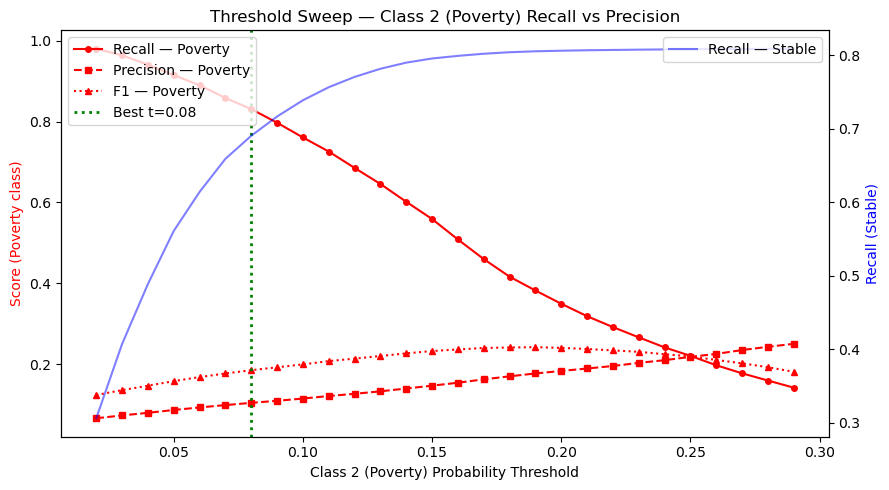


=== FT-Transformer — Tuned Threshold (t2=0.08) ===
              precision    recall  f1-score   support

      Stable     0.9185    0.6906    0.7884    233793
Near Poverty     0.2254    0.0137    0.0258     38456
     Poverty     0.1040    0.8311    0.1849     15534
Deep Poverty     0.5263    0.0670    0.1189     16585

    accuracy                         0.5783    304368
   macro avg     0.4436    0.4006    0.2795    304368
weighted avg     0.7680    0.5783    0.6248    304368


Side-by-side recall comparison:
  Class            Argmax Recall   Tuned Recall
----------------------------------------------
  Stable                  0.8091         0.6906  (-0.1185)
  Near Poverty            0.4825         0.0137  (-0.4688)
  Poverty                 0.0735         0.8311  (+0.7576)
  Deep Poverty            0.3993         0.0670  (-0.3323)


In [25]:
# ═════════════════════════════════════════════════════════════════════════════
# Per-class threshold tuning to improve Poverty recall
#
# Instead of argmax (which picks whichever class has highest prob),
# we set per-class thresholds. A sample is assigned to class i if
# prob[:, i] > threshold[i]
# sweep threshold for Class 2 (Poverty) to find the value
# that maximises recall without destroying precision beyond acceptable bounds.
# ═════════════════════════════════════════════════════════════════════════════

# Sweep threshold for Class 2 only
thresholds_to_try = np.arange(0.02, 0.30, 0.01)
sweep_results = []

for t2 in thresholds_to_try:
    # Start with argmax predictions
    preds_tuned = all_preds.copy()

    # Override: if prob[:, 2] > t2, predict Class 2
    # (only override when the model isn't already more confident about another class)
    override_mask = all_probs[:, 2] > t2
    preds_tuned[override_mask] = 2

    recall_2    = (preds_tuned[all_targets == 2] == 2).mean()
    precision_2 = (all_targets[preds_tuned == 2] == 2).mean() if (preds_tuned == 2).sum() > 0 else 0
    f1_2        = (2 * precision_2 * recall_2 / (precision_2 + recall_2)
                   if (precision_2 + recall_2) > 0 else 0)
    # Also track that we haven't destroyed Stable recall too much
    recall_stable = (preds_tuned[all_targets == 0] == 0).mean()

    sweep_results.append({
        'threshold': t2,
        'recall_2': recall_2,
        'precision_2': precision_2,
        'f1_2': f1_2,
        'recall_stable': recall_stable,
    })

sweep_df = pd.DataFrame(sweep_results)

print(f"\nBaseline (argmax):  Recall={sweep_df.iloc[0]['recall_2']:.3f}  "
      f"Precision={sweep_df.iloc[0]['precision_2']:.3f}  "
      f"F1={sweep_df.iloc[0]['f1_2']:.3f}")

# find threshold that maximises recall@Class2 with precision >= 0.10
viable = sweep_df[sweep_df['precision_2'] >= 0.10]
if len(viable) > 0:
    best_row = viable.loc[viable['recall_2'].idxmax()]
    print(f"Best threshold (precision≥0.10): t={best_row['threshold']:.2f}  "
          f"Recall={best_row['recall_2']:.3f}  "
          f"Precision={best_row['precision_2']:.3f}  "
          f"F1={best_row['f1_2']:.3f}")

#  sweep table
print(f"\n{'Threshold':>10}  {'Recall@2':>9}  {'Prec@2':>7}  {'F1@2':>6}  {'Recall@Stable':>13}")
print("-" * 55)
for _, row in sweep_df.iterrows():
    marker = " ← best" if len(viable) > 0 and row['threshold'] == best_row['threshold'] else ""
    print(f"  {row['threshold']:>8.2f}  {row['recall_2']:>9.3f}  "
          f"{row['precision_2']:>7.3f}  {row['f1_2']:>6.3f}  "
          f"{row['recall_stable']:>13.3f}{marker}")

#   sweep 
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(sweep_df['threshold'], sweep_df['recall_2'],    'r-o', ms=4, label='Recall — Poverty')
ax1.plot(sweep_df['threshold'], sweep_df['precision_2'], 'r--s', ms=4, label='Precision — Poverty')
ax1.plot(sweep_df['threshold'], sweep_df['f1_2'],        'r:^', ms=4, label='F1 — Poverty')
ax2.plot(sweep_df['threshold'], sweep_df['recall_stable'], 'b-', ms=3, alpha=0.5, label='Recall — Stable')

if len(viable) > 0:
    ax1.axvline(x=best_row['threshold'], color='green', linestyle=':', lw=2,
                label=f"Best t={best_row['threshold']:.2f}")

ax1.set_xlabel('Class 2 (Poverty) Probability Threshold')
ax1.set_ylabel('Score (Poverty class)', color='r')
ax2.set_ylabel('Recall (Stable)', color='b')
ax1.set_title('Threshold Sweep — Class 2 (Poverty) Recall vs Precision')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/ft_threshold_sweep_class2.png', dpi=150, bbox_inches='tight')
plt.show()

#  best threshold 
if len(viable) > 0:
    preds_best = all_preds.copy()
    preds_best[all_probs[:, 2] > best_row['threshold']] = 2

    print(f"\n=== FT-Transformer — Tuned Threshold (t2={best_row['threshold']:.2f}) ===")
    print(classification_report(all_targets, preds_best,
                                 target_names=CLASS_NAMES, digits=4))

    print("\nSide-by-side recall comparison:")
    print(f"  {'Class':<15} {'Argmax Recall':>14}  {'Tuned Recall':>13}")
    print("-" * 46)
    for i, name in enumerate(CLASS_NAMES):
        r_orig  = (all_preds[all_targets == i] == i).mean()
        r_tuned = (preds_best[all_targets == i] == i).mean()
        delta   = r_tuned - r_orig
        print(f"  {name:<15} {r_orig:>14.4f}  {r_tuned:>13.4f}  ({delta:+.4f})")